# Notebook 03 — Descriptive EDA
**Project:** Carbon-Aware Scheduling for Data Centres  
**Module:** IS6611 Applied Research in Business Analytics — Group 11

---

## Purpose
Exploratory Data Analysis across three layers — demand, supply, and their intersection.  
This phase answers: **When does Summit consume power? When is the TVA grid cleanest? Do these currently align or misalign?**

| Section | Focus | Key chart |
|---------|-------|-----------|
| 2.1 Demand | ORNL power consumption profiles | Hourly utilisation heatmap |
| 2.2 Supply | TVA grid carbon intensity patterns | CI heatmap (hour × month) |
| 2.3 Integrated | The scheduling opportunity | CI curve vs shiftable energy |

> All data comes from processed files only — no new fetches or transformations.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import seaborn as sns

from config.settings import PROCESSED_DATA_DIR

# ── Load all three processed datasets ────────────────────────────────
demand     = pd.read_csv(PROJECT_ROOT / 'data/processed/demand_engineered.csv',
                         parse_dates=['local_hour'])
supply     = pd.read_csv(PROJECT_ROOT / 'data/processed/supply_engineered.csv',
                         parse_dates=['datetime'])
integrated = pd.read_csv(PROJECT_ROOT / 'data/processed/integrated.csv',
                         parse_dates=['local_hour'])

# ── Chart output folder ───────────────────────────────────────────────
EDA_DIR = PROJECT_ROOT / 'data' / 'processed'
EDA_DIR.mkdir(parents=True, exist_ok=True)

# ── Consistent styling ────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
BLUE   = '#1565C0'
GREEN  = '#2E7D32'
RED    = '#C62828'
ORANGE = '#E65100'
PURPLE = '#6A1B9A'
GREY   = '#546E7A'

SNAPSHOT_DATES = sorted(demand['snapshot_date'].unique())
DAY_COLOURS    = ['#1565C0','#E65100','#2E7D32','#6A1B9A','#C62828']

print(f'Demand    : {demand.shape}    Supply: {supply.shape}    Integrated: {integrated.shape}')
print(f'Snapshot days: {SNAPSHOT_DATES}')

Demand    : (120, 15)    Supply: (35064, 27)    Integrated: (120, 47)
Snapshot days: ['2020-01-20', '2020-08-20', '2021-02-20', '2021-08-10', '2022-01-20']


---
## Section 2.1 — Demand: Power Consumption Profiles

### 2.1.1 Hourly active power profile across snapshot days

**What it shows:** How active cluster power (kW) changes hour by hour on each of the 5 snapshot days.  
**Why it matters:** If Summit has predictable busy/idle periods, the scheduler can anticipate when jobs will be submitted and pre-identify green windows in advance.

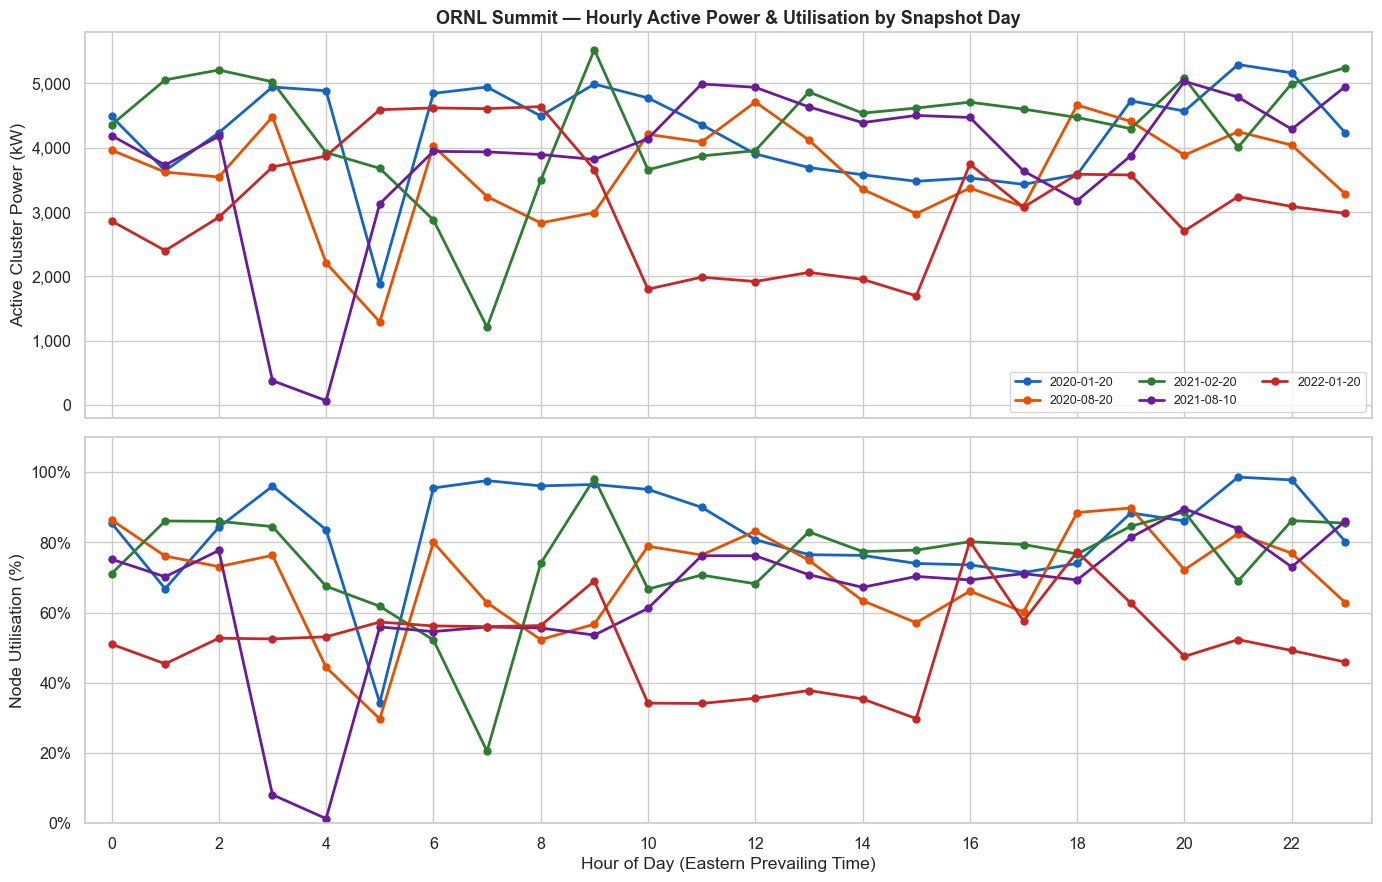

Key statistics:
              active_power_kW                   utilization_rate            
                         mean      min      max             mean   min   max
snapshot_date                                                               
2020-01-20            4232.93  1883.94  5289.05             0.83  0.34  0.99
2020-08-20            3607.73  1291.66  4707.26             0.70  0.30  0.90
2021-02-20            4299.36  1211.07  5519.76             0.75  0.20  0.98
2021-08-10            3875.79    69.52  5028.62             0.65  0.01  0.90
2022-01-20            3135.10  1696.86  4635.93             0.51  0.30  0.80


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for i, (date, grp) in enumerate(demand.groupby('snapshot_date')):
    col = DAY_COLOURS[i]
    grp = grp.sort_values('hour_of_day')

    # Top panel: active power (kW)
    axes[0].plot(grp['hour_of_day'], grp['active_power_kW'],
                 marker='o', ms=5, lw=2, color=col, label=date)

    # Bottom panel: utilisation rate (%)
    axes[1].plot(grp['hour_of_day'], grp['utilization_rate'] * 100,
                 marker='o', ms=5, lw=2, color=col, label=date)

axes[0].set_ylabel('Active Cluster Power (kW)')
axes[0].set_title('ORNL Summit — Hourly Active Power & Utilisation by Snapshot Day',
                  fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9, ncol=3)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].set_ylabel('Node Utilisation (%)')
axes[1].set_xlabel('Hour of Day (Eastern Prevailing Time)')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[1].set_ylim(0, 110)

for ax in axes:
    ax.set_xticks(range(0, 24, 2))
    ax.set_xlim(-0.5, 23.5)

plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_demand_hourly_profile.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key statistics:')
print(demand.groupby('snapshot_date')[['active_power_kW','utilization_rate']]
      .agg(['mean','min','max']).round(2).to_string())

### 2.1.2 Active vs idle power split

**What it shows:** For each snapshot day, how total cluster power splits between  
job-driven (active, shiftable) and standby (idle, fixed overhead).  
**Why it matters:** Only active energy can be scheduled to a greener window.  
Idle standby power is unavoidable and not included in carbon savings calculations.

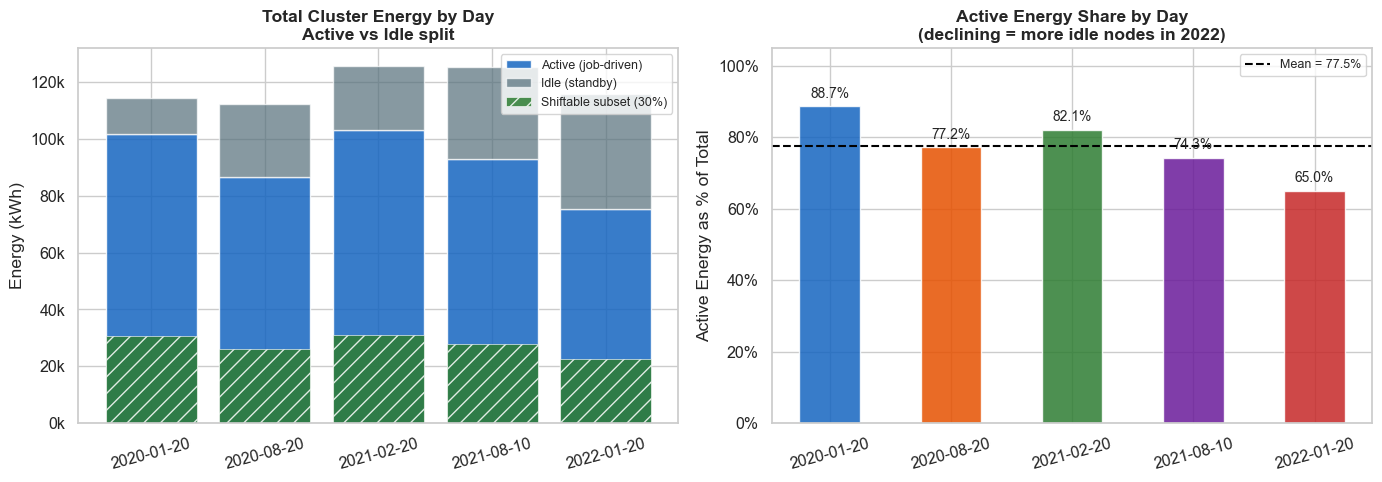

snapshot_date  active_kWh     idle_kWh  shiftable_kWh  active_pct
   2020-01-20 101590.3212 12884.985745   30477.096970   88.744310
   2020-08-20  86585.4833 25630.887950   25975.646220   77.159404
   2021-02-20 103184.6309 22513.653860   30955.390670   82.089132
   2021-08-10  93018.9777 32221.958030   27905.694454   74.272024
   2022-01-20  75242.4711 40470.384240   22572.742250   65.025162


In [3]:
day_energy = demand.groupby('snapshot_date').agg(
    active_kWh   = ('active_energy_kWh',   'sum'),
    idle_kWh     = ('idle_power_kW',        'sum'),
    shiftable_kWh= ('shiftable_energy_kWh', 'sum'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: stacked bar — active vs idle ───────────────────────────────
x = range(len(day_energy))
axes[0].bar(x, day_energy['active_kWh'], color=BLUE,   alpha=0.85, label='Active (job-driven)')
axes[0].bar(x, day_energy['idle_kWh'],   color=GREY,   alpha=0.70, label='Idle (standby)',
            bottom=day_energy['active_kWh'])
axes[0].bar(x, day_energy['shiftable_kWh'], color=GREEN, alpha=0.85,
            label='Shiftable subset (30%)', hatch='//', edgecolor='white', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(day_energy['snapshot_date'], rotation=15)
axes[0].set_ylabel('Energy (kWh)')
axes[0].set_title('Total Cluster Energy by Day\nActive vs Idle split', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))

# ── Right: active % of total ─────────────────────────────────────────
day_energy['active_pct'] = day_energy['active_kWh'] / (
    day_energy['active_kWh'] + day_energy['idle_kWh']) * 100
bars = axes[1].bar(x, day_energy['active_pct'], color=DAY_COLOURS, alpha=0.85, width=0.5)
axes[1].bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(day_energy['snapshot_date'], rotation=15)
axes[1].set_ylabel('Active Energy as % of Total')
axes[1].set_title('Active Energy Share by Day\n(declining = more idle nodes in 2022)',
                  fontweight='bold')
axes[1].set_ylim(0, 105)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[1].axhline(day_energy['active_pct'].mean(), color='black',
                linestyle='--', lw=1.5, label=f'Mean = {day_energy["active_pct"].mean():.1f}%')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_demand_active_idle_split.png', dpi=150, bbox_inches='tight')
plt.show()

print(day_energy.to_string(index=False))

### 2.1.3 Hourly utilisation heatmap

**What it shows:** A 5 × 24 grid where colour encodes node utilisation rate.  
Dark blue = fully utilised. Light = mostly idle.  
**Why it matters:** Reveals whether there are consistent low-utilisation hours  
across days — these are the natural windows for scheduling deferred workloads.

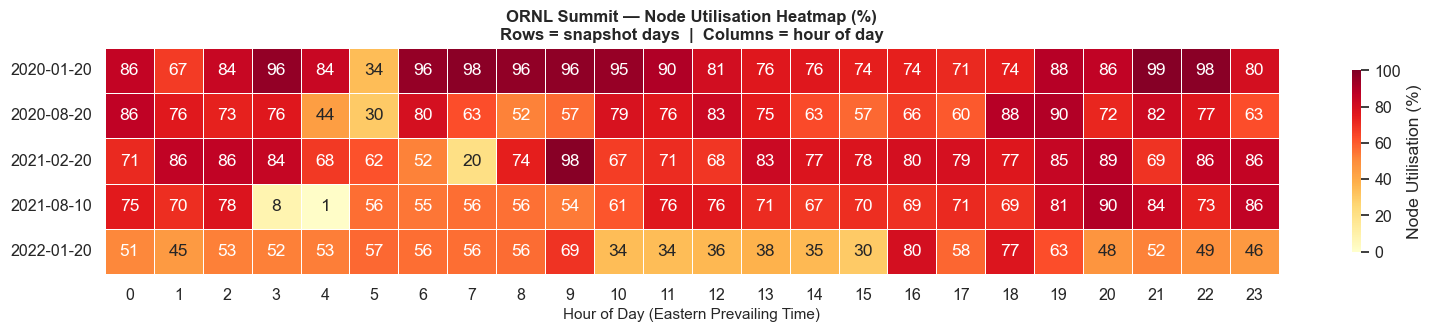

In [4]:
# Pivot to matrix: rows = snapshot days, columns = hours
util_matrix = demand.pivot_table(
    index='snapshot_date',
    columns='hour_of_day',
    values='utilization_rate'
) * 100  # convert to percentage

fig, ax = plt.subplots(figsize=(16, 3.5))

sns.heatmap(
    util_matrix,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Node Utilisation (%)', 'shrink': 0.8},
    vmin=0, vmax=100
)

ax.set_xlabel('Hour of Day (Eastern Prevailing Time)', fontsize=11)
ax.set_ylabel('')
ax.set_title('ORNL Summit — Node Utilisation Heatmap (%)\nRows = snapshot days  |  Columns = hour of day',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_demand_utilisation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2.2 — Supply: TVA Grid Carbon Intensity Patterns

### 2.2.1 Carbon intensity by hour of day

**What it shows:** The mean and spread of CI for each hour of the day across 4 years.  
**Why it matters:** If CI is systematically lower at certain hours, those are the target windows for scheduling delay-tolerant workloads.

/tmp/claude-501/ipykernel_13552/3207899312.py:38: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13552/3207899312.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(EDA_DIR / 'eda_supply_ci_by_hour.png', dpi=150, bbox_inches='tight')
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


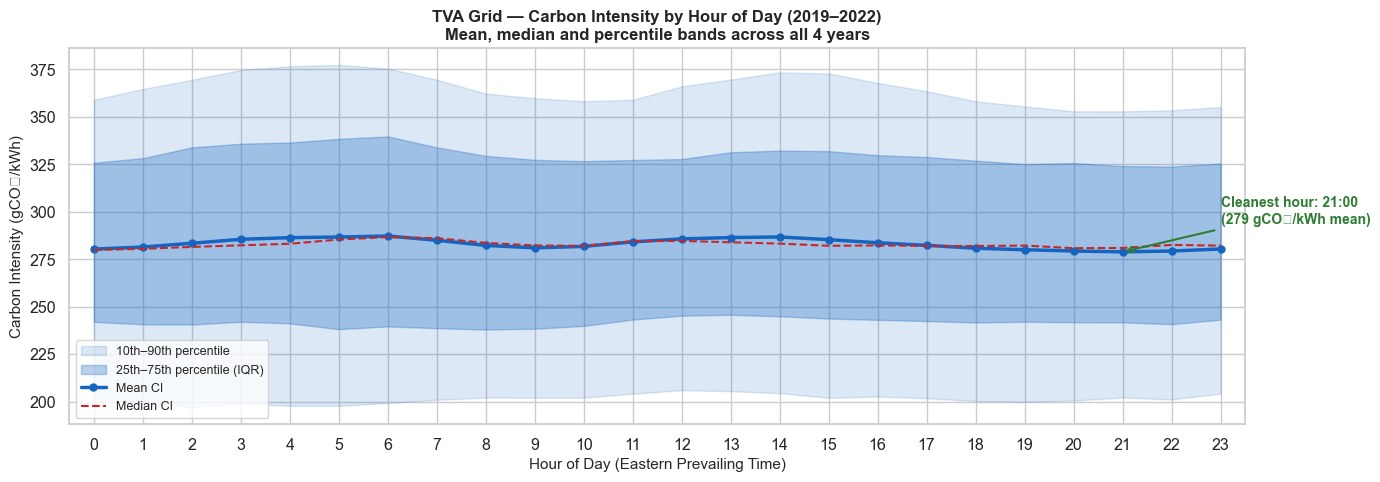

Cleanest mean CI: hour 21:00  → 278.9 gCO₂/kWh
Dirtiest mean CI: hour 06:00  → 287.3 gCO₂/kWh
Average daily range (mean max - mean min): 8.4 gCO₂/kWh


In [5]:
ci_by_hour = supply.groupby('hour_of_day')['carbon_intensity_gCO2_per_kWh'].agg(
    mean='mean', median='median',
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90),
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(ci_by_hour['hour_of_day'], ci_by_hour['p10'], ci_by_hour['p90'],
                alpha=0.15, color=BLUE, label='10th–90th percentile')
ax.fill_between(ci_by_hour['hour_of_day'], ci_by_hour['p25'], ci_by_hour['p75'],
                alpha=0.30, color=BLUE, label='25th–75th percentile (IQR)')
ax.plot(ci_by_hour['hour_of_day'], ci_by_hour['mean'],
        color=BLUE, lw=2.5, marker='o', ms=5, label='Mean CI')
ax.plot(ci_by_hour['hour_of_day'], ci_by_hour['median'],
        color=RED, lw=1.5, linestyle='--', label='Median CI')

# Annotate the cleanest hour
cleanest_hour = ci_by_hour.loc[ci_by_hour['mean'].idxmin(), 'hour_of_day']
cleanest_ci   = ci_by_hour['mean'].min()
ax.annotate(f'Cleanest hour: {int(cleanest_hour):02d}:00\n({cleanest_ci:.0f} gCO₂/kWh mean)',
            xy=(cleanest_hour, cleanest_ci),
            xytext=(cleanest_hour + 2, cleanest_ci + 15),
            arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5),
            color=GREEN, fontsize=10, fontweight='bold')

ax.set_xlabel('Hour of Day (Eastern Prevailing Time)', fontsize=11)
ax.set_ylabel('Carbon Intensity (gCO₂/kWh)', fontsize=11)
ax.set_title('TVA Grid — Carbon Intensity by Hour of Day (2019–2022)\n'
             'Mean, median and percentile bands across all 4 years',
             fontsize=12, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.set_xlim(-0.5, 23.5)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_supply_ci_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Cleanest mean CI: hour {int(cleanest_hour):02d}:00  → {cleanest_ci:.1f} gCO₂/kWh')
dirtiest_hour = ci_by_hour.loc[ci_by_hour['mean'].idxmax(), 'hour_of_day']
dirtiest_ci   = ci_by_hour['mean'].max()
print(f'Dirtiest mean CI: hour {int(dirtiest_hour):02d}:00  → {dirtiest_ci:.1f} gCO₂/kWh')
print(f'Average daily range (mean max - mean min): {dirtiest_ci - cleanest_ci:.1f} gCO₂/kWh')

### 2.2.2 Carbon intensity heatmap — Hour × Month

**What it shows:** Mean CI for each combination of hour of day and month of year.  
This is the most important chart in Phase 2 — it reveals the two-dimensional structure  
of scheduling opportunity: which hours in which months offer the lowest carbon windows.  
**Why it matters:** The forecasting model in Phase 3 must learn these patterns.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/tmp/claude-501/ipykernel_13552/2498545270.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13552/2498545270.py:29: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(EDA_DIR / 'eda_supply_ci_heatmap_hour_month.png', dpi=150, bbox_inches='tight')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


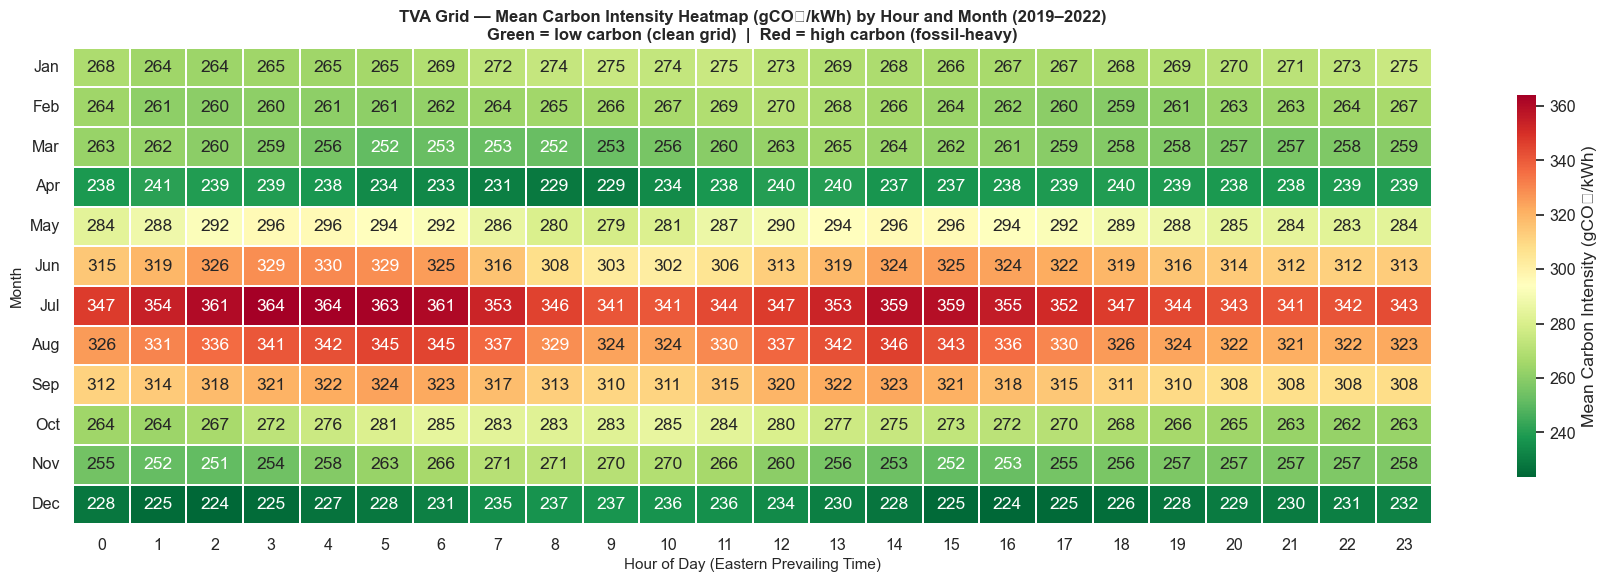

Cleanest combination: Dec at hour 16:00 → 223.7 gCO₂/kWh
Dirtiest combination: Jul at hour 04:00 → 363.9 gCO₂/kWh


In [6]:
ci_heatmap = supply.groupby(['month', 'hour_of_day'])['carbon_intensity_gCO2_per_kWh'] \
    .mean().unstack('hour_of_day')

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ci_heatmap.index = month_labels

fig, ax = plt.subplots(figsize=(18, 6))

im = sns.heatmap(
    ci_heatmap,
    ax=ax,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.0f',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Mean Carbon Intensity (gCO₂/kWh)', 'shrink': 0.8},
)

ax.set_xlabel('Hour of Day (Eastern Prevailing Time)', fontsize=11)
ax.set_ylabel('Month', fontsize=11)
ax.set_title('TVA Grid — Mean Carbon Intensity Heatmap (gCO₂/kWh) by Hour and Month (2019–2022)\n'
             'Green = low carbon (clean grid)  |  Red = high carbon (fossil-heavy)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_supply_ci_heatmap_hour_month.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight: find the globally cleanest and dirtiest combination
flat = ci_heatmap.stack()
best = flat.idxmin()
worst = flat.idxmax()
print(f'Cleanest combination: {best[0]} at hour {best[1]:02d}:00 → {flat.min():.1f} gCO₂/kWh')
print(f'Dirtiest combination: {worst[0]} at hour {worst[1]:02d}:00 → {flat.max():.1f} gCO₂/kWh')

### 2.2.3 Annual carbon intensity trend (2019–2022)

**What it shows:** Monthly mean CI across the 4-year period.  
**Why it matters:** Confirms whether the TVA grid is decarbonising over time.  
A declining trend strengthens the case for carbon-aware scheduling —  
future savings will be even larger as the grid gets cleaner.

/tmp/claude-501/ipykernel_13552/1967507990.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13552/1967507990.py:35: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(EDA_DIR / 'eda_supply_ci_trend.png', dpi=150, bbox_inches='tight')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


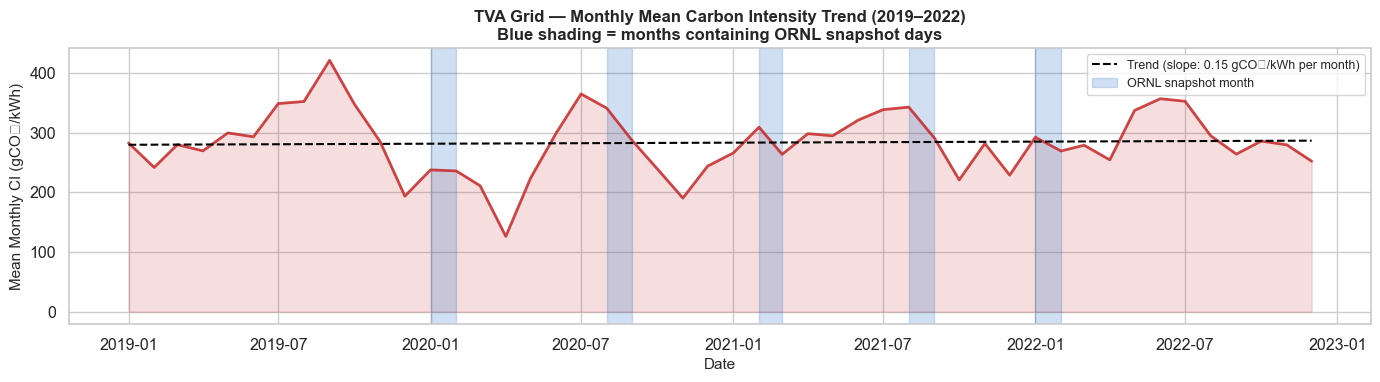

Mean CI 2019: 301.4 gCO₂/kWh
Mean CI 2022: 293.3 gCO₂/kWh
Trend slope : 0.146 gCO₂/kWh per month


In [7]:
supply['year_month'] = supply['datetime'].dt.to_period('M')
monthly_ci = supply.groupby('year_month')['carbon_intensity_gCO2_per_kWh'].mean().reset_index()
monthly_ci['year_month_dt'] = monthly_ci['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(monthly_ci['year_month_dt'], monthly_ci['carbon_intensity_gCO2_per_kWh'],
        color=RED, lw=2, alpha=0.85)
ax.fill_between(monthly_ci['year_month_dt'],
                monthly_ci['carbon_intensity_gCO2_per_kWh'],
                alpha=0.15, color=RED)

# Trend line
x_num = np.arange(len(monthly_ci))
z     = np.polyfit(x_num, monthly_ci['carbon_intensity_gCO2_per_kWh'], 1)
p     = np.poly1d(z)
ax.plot(monthly_ci['year_month_dt'], p(x_num),
        color='black', lw=1.5, linestyle='--', label=f'Trend (slope: {z[0]:.2f} gCO₂/kWh per month)')

# Shade ORNL snapshot months
ornl_months = ['2020-01','2020-08','2021-02','2021-08','2022-01']
for m in ornl_months:
    month_dt = pd.Timestamp(m)
    ax.axvspan(month_dt, month_dt + pd.DateOffset(months=1),
               alpha=0.2, color=BLUE, label='ORNL snapshot month' if m == ornl_months[0] else '')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Mean Monthly CI (gCO₂/kWh)', fontsize=11)
ax.set_title('TVA Grid — Monthly Mean Carbon Intensity Trend (2019–2022)\n'
             'Blue shading = months containing ORNL snapshot days',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_supply_ci_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean CI 2019: {supply[supply["year"]==2019]["carbon_intensity_gCO2_per_kWh"].mean():.1f} gCO₂/kWh')
print(f'Mean CI 2022: {supply[supply["year"]==2022]["carbon_intensity_gCO2_per_kWh"].mean():.1f} gCO₂/kWh')
print(f'Trend slope : {z[0]:.3f} gCO₂/kWh per month')

### 2.2.4 Carbon intensity by season

**What it shows:** CI distribution broken down by season.  
**Why it matters:** Reveals whether summer or winter offers cleaner scheduling windows —  
relevant when deciding how to weight the 5 snapshot days in the annual projection.

/tmp/claude-501/ipykernel_13552/769761037.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(season_data, labels=season_order, patch_artist=True,


/tmp/claude-501/ipykernel_13552/769761037.py:34: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13552/769761037.py:35: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(EDA_DIR / 'eda_supply_ci_seasonal.png', dpi=150, bbox_inches='tight')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


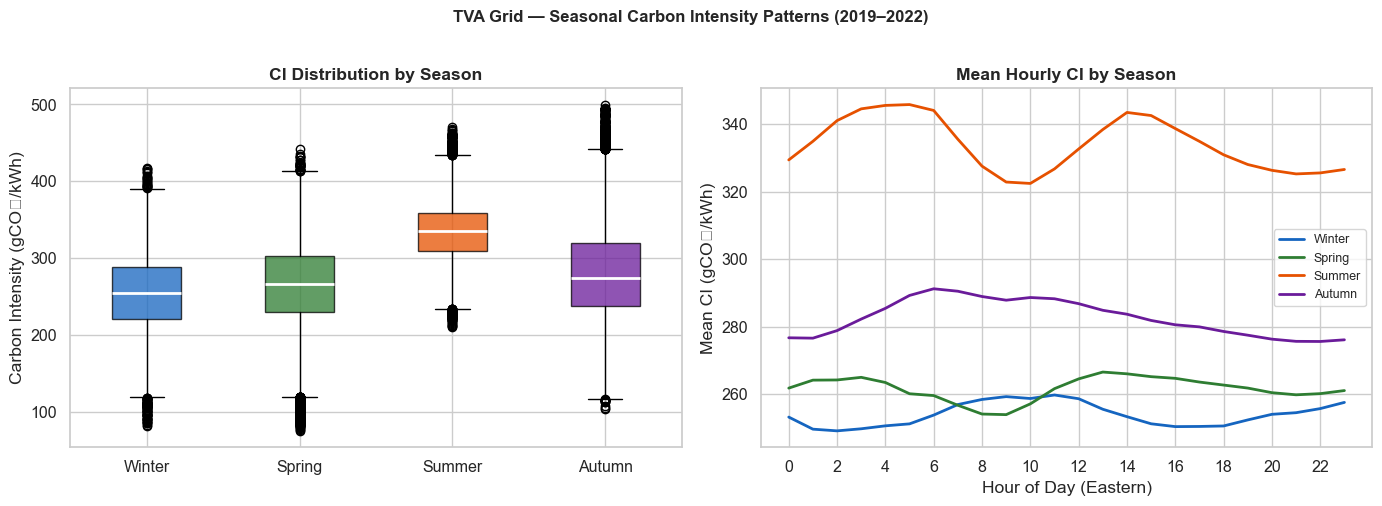

Mean CI by season:
season
Winter    253.9
Spring    261.6
Summer    333.9
Autumn    282.6


In [8]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colours = {'Winter': '#1565C0', 'Spring': '#2E7D32',
                  'Summer': '#E65100', 'Autumn': '#6A1B9A'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: box plots ─────────────────────────────────────────────────
season_data = [supply[supply['season'] == s]['carbon_intensity_gCO2_per_kWh'].dropna()
               for s in season_order]
bp = axes[0].boxplot(season_data, labels=season_order, patch_artist=True,
                     medianprops={'color': 'white', 'linewidth': 2})
for patch, season in zip(bp['boxes'], season_order):
    patch.set_facecolor(season_colours[season])
    patch.set_alpha(0.75)

axes[0].set_ylabel('Carbon Intensity (gCO₂/kWh)')
axes[0].set_title('CI Distribution by Season', fontweight='bold')

# ── Right: mean CI by hour, split by season ──────────────────────────
for season in season_order:
    s_data = supply[supply['season'] == season] \
        .groupby('hour_of_day')['carbon_intensity_gCO2_per_kWh'].mean()
    axes[1].plot(s_data.index, s_data.values,
                 lw=2, color=season_colours[season], label=season)

axes[1].set_xlabel('Hour of Day (Eastern)')
axes[1].set_ylabel('Mean CI (gCO₂/kWh)')
axes[1].set_title('Mean Hourly CI by Season', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(0, 24, 2))

plt.suptitle('TVA Grid — Seasonal Carbon Intensity Patterns (2019–2022)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_supply_ci_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean CI by season:')
print(supply.groupby('season')['carbon_intensity_gCO2_per_kWh']
      .mean().reindex(season_order).round(1).to_string())

### 2.2.5 Daily CI range — the scheduling opportunity

**What it shows:** For every day in 4 years, the difference between the maximum and minimum  
CI within that calendar day (i.e., the scheduling opportunity window).  
**Why it matters:** A large range means a scheduler can save significant carbon by  
choosing the right hour. A small range means little benefit from temporal shifting.

/tmp/claude-501/ipykernel_13552/2896840459.py:46: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13552/2896840459.py:47: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(EDA_DIR / 'eda_supply_daily_ci_range.png', dpi=150, bbox_inches='tight')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


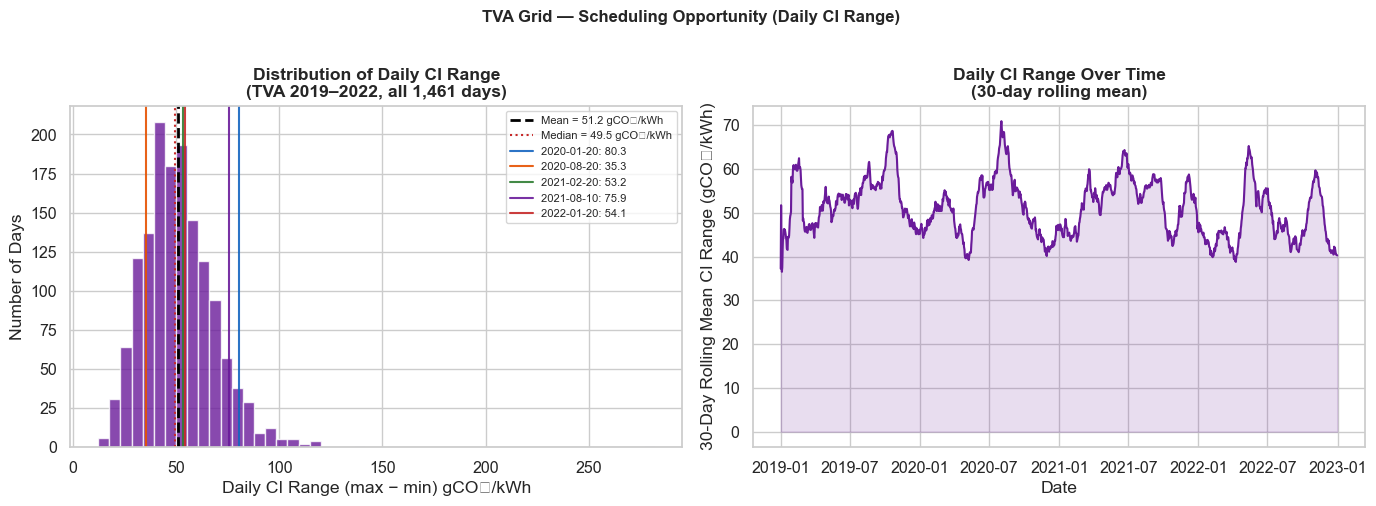

Mean daily CI range : 51.2 gCO₂/kWh
Median daily range  : 49.5 gCO₂/kWh
Days with range > 50: 715 / 1461 (49%)


In [9]:
daily_range = supply.groupby('date_key')['carbon_intensity_gCO2_per_kWh'].agg(
    ci_min='min', ci_max='max'
).reset_index()
daily_range['ci_range'] = daily_range['ci_max'] - daily_range['ci_min']
daily_range['date'] = pd.to_datetime(daily_range['date_key'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram of daily CI ranges ──────────────────────────────
axes[0].hist(daily_range['ci_range'], bins=50, color=PURPLE, alpha=0.8, edgecolor='white')
axes[0].axvline(daily_range['ci_range'].mean(), color='black', lw=2, linestyle='--',
                label=f'Mean = {daily_range["ci_range"].mean():.1f} gCO₂/kWh')
axes[0].axvline(daily_range['ci_range'].median(), color=RED, lw=1.5, linestyle=':',
                label=f'Median = {daily_range["ci_range"].median():.1f} gCO₂/kWh')

# Mark the 5 ORNL snapshot days
ornl_ranges = {
    '2020-01-20': daily_range[daily_range['date_key'] == '2020-01-20']['ci_range'].values[0],
    '2020-08-20': daily_range[daily_range['date_key'] == '2020-08-20']['ci_range'].values[0],
    '2021-02-20': daily_range[daily_range['date_key'] == '2021-02-20']['ci_range'].values[0],
    '2021-08-10': daily_range[daily_range['date_key'] == '2021-08-10']['ci_range'].values[0],
    '2022-01-20': daily_range[daily_range['date_key'] == '2022-01-20']['ci_range'].values[0],
}
for i, (d, r) in enumerate(ornl_ranges.items()):
    axes[0].axvline(r, color=DAY_COLOURS[i], lw=1.5, alpha=0.9,
                    label=f'{d}: {r:.1f}')

axes[0].set_xlabel('Daily CI Range (max − min) gCO₂/kWh')
axes[0].set_ylabel('Number of Days')
axes[0].set_title('Distribution of Daily CI Range\n(TVA 2019–2022, all 1,461 days)',
                  fontweight='bold')
axes[0].legend(fontsize=8)

# ── Right: time series of rolling 30-day mean CI range ───────────────
daily_range_sorted = daily_range.sort_values('date')
rolling_range = daily_range_sorted['ci_range'].rolling(30, min_periods=1).mean()
axes[1].plot(daily_range_sorted['date'], rolling_range, color=PURPLE, lw=1.5)
axes[1].fill_between(daily_range_sorted['date'], rolling_range, alpha=0.15, color=PURPLE)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('30-Day Rolling Mean CI Range (gCO₂/kWh)')
axes[1].set_title('Daily CI Range Over Time\n(30-day rolling mean)',
                  fontweight='bold')

plt.suptitle('TVA Grid — Scheduling Opportunity (Daily CI Range)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_supply_daily_ci_range.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean daily CI range : {daily_range["ci_range"].mean():.1f} gCO₂/kWh')
print(f'Median daily range  : {daily_range["ci_range"].median():.1f} gCO₂/kWh')
print(f'Days with range > 50: {(daily_range["ci_range"] > 50).sum()} / {len(daily_range)} ({(daily_range["ci_range"] > 50).mean():.0%})')

### 2.2.6 The moving clean window — why forecasting is necessary

**The most important finding in Phase 2.**

There is a subtle but decisive contrast in the data:

- Averaged across 4 years, the spread between the cleanest and dirtiest *hour of day* is only **~8 gCO₂/kWh** — almost flat. This would suggest "time of day barely matters."
- Yet within **any single day**, the CI range averages **~51 gCO₂/kWh** — six times larger.

The resolution: on the TVA grid the clean window **does not sit at a fixed hour**. Unlike a solar-dominated grid (where midday is reliably cleanest), TVA's cleanest hour moves unpredictably from day to day, driven by nuclear maintenance cycles, hydro availability, and demand swings.

**Implication for the project:** a naive "always run jobs at hour X" rule captures almost none of the available saving, because X changes every day. To exploit the 51 gCO₂/kWh daily opportunity you must *forecast* where tomorrow's clean window will be. This chart is the empirical justification for Phase 3 (forecasting) and Phase 4 (optimisation)."

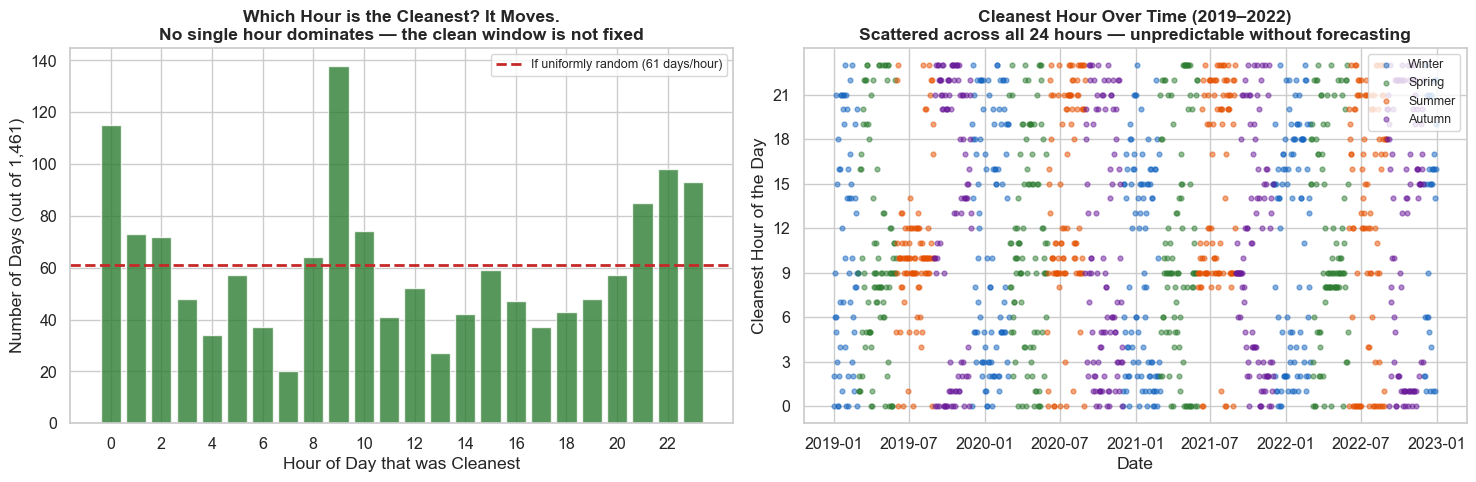

Most frequently cleanest hour : 09:00
  …but it is cleanest on only 138 of 1461 days (9.4%)
  A fixed-hour rule would miss the clean window on 90.6% of days.
Hours that are the cleanest on at least 10 days: 24 of 24


In [10]:
# For every day, find WHICH hour had the lowest carbon intensity
cleanest_hour_per_day = (
    supply.loc[supply.groupby('date_key')['carbon_intensity_gCO2_per_kWh'].idxmin()]
    [['date_key', 'hour_of_day', 'carbon_intensity_gCO2_per_kWh', 'month', 'season']]
    .rename(columns={'hour_of_day': 'cleanest_hour'})
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: how often is each hour the cleanest of its day? ────────────
hour_counts = cleanest_hour_per_day['cleanest_hour'].value_counts().sort_index()
hour_counts = hour_counts.reindex(range(24), fill_value=0)
bars = axes[0].bar(hour_counts.index, hour_counts.values,
                   color=GREEN, alpha=0.8, edgecolor='white')
# If clean window were fixed, ONE bar would hold ~1461. Instead it's spread out.
axes[0].axhline(len(cleanest_hour_per_day) / 24, color=RED, lw=2, linestyle='--',
                label=f'If uniformly random ({len(cleanest_hour_per_day)/24:.0f} days/hour)')
axes[0].set_xlabel('Hour of Day that was Cleanest')
axes[0].set_ylabel('Number of Days (out of 1,461)')
axes[0].set_title('Which Hour is the Cleanest? It Moves.\n'
                  'No single hour dominates — the clean window is not fixed',
                  fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=9)

# ── Right: cleanest hour over the calendar — visual scatter ──────────
cleanest_hour_per_day['date'] = pd.to_datetime(cleanest_hour_per_day['date_key'])
season_colours = {'Winter': '#1565C0', 'Spring': '#2E7D32',
                  'Summer': '#E65100', 'Autumn': '#6A1B9A'}
for season, col in season_colours.items():
    sub = cleanest_hour_per_day[cleanest_hour_per_day['season'] == season]
    axes[1].scatter(sub['date'], sub['cleanest_hour'],
                    s=12, alpha=0.5, color=col, label=season)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cleanest Hour of the Day')
axes[1].set_title('Cleanest Hour Over Time (2019–2022)\n'
                  'Scattered across all 24 hours — unpredictable without forecasting',
                  fontweight='bold')
axes[1].set_yticks(range(0, 24, 3))
axes[1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_supply_moving_clean_window.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify the unpredictability
most_common_hour  = hour_counts.idxmax()
most_common_count = hour_counts.max()
pct_in_top_hour   = most_common_count / len(cleanest_hour_per_day) * 100
print(f'Most frequently cleanest hour : {most_common_hour:02d}:00')
print(f'  …but it is cleanest on only {most_common_count} of {len(cleanest_hour_per_day)} days ({pct_in_top_hour:.1f}%)')
print(f'  A fixed-hour rule would miss the clean window on {100-pct_in_top_hour:.1f}% of days.')
print(f'Hours that are the cleanest on at least 10 days: {(hour_counts >= 10).sum()} of 24')

---
## Section 2.3 — Integrated: The Scheduling Opportunity

### 2.3.1 CI curve vs shiftable energy — all 5 snapshot days

**What it shows:** For each of the 5 observed days: the actual TVA carbon intensity  
across 24 hours (line) alongside the volume of shiftable energy in each hour (bars).  
The green dashed line marks the day's minimum CI — the optimal target.  
**Why it matters:** Directly visualises the mismatch between when jobs run and  
when the grid is cleanest — the core evidence for the scheduling intervention.

/tmp/claude-501/ipykernel_13552/2676058218.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13552/2676058218.py:44: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(EDA_DIR / 'eda_integrated_ci_vs_shiftable.png', dpi=150, bbox_inches='tight')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


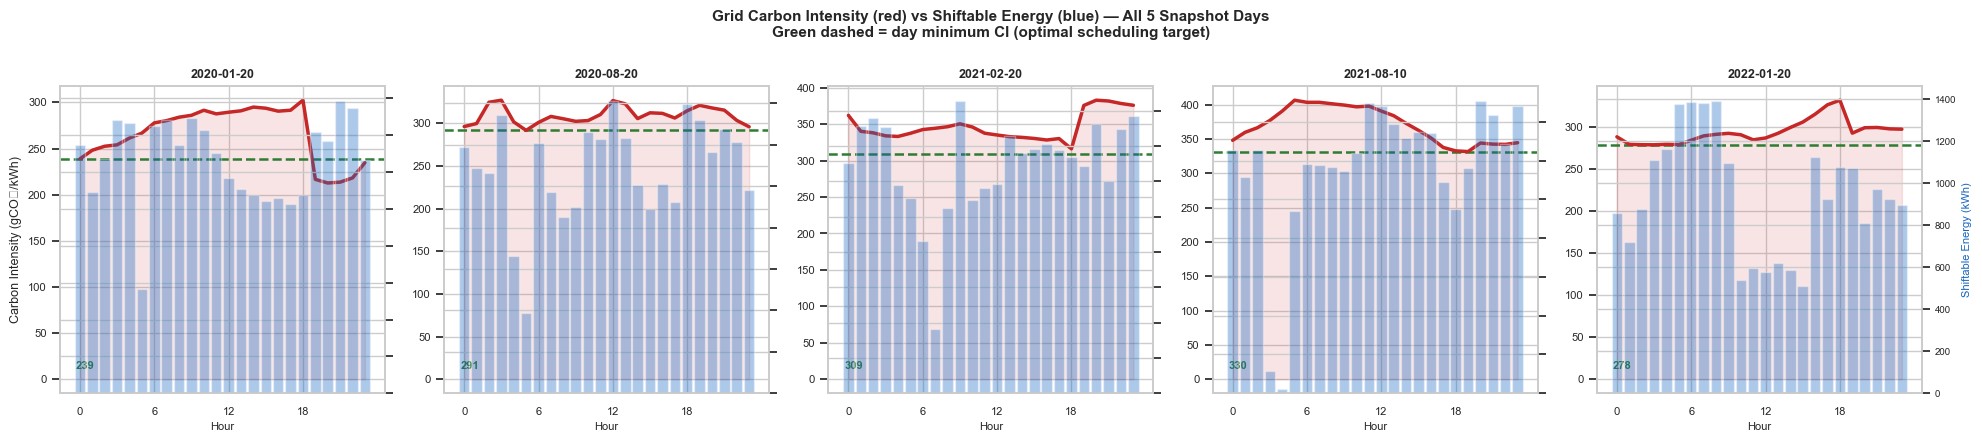

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5), sharey=False)

for i, (date, grp) in enumerate(integrated.groupby('snapshot_date')):
    grp  = grp.sort_values('hour_of_day')
    ax   = axes[i]
    ax2  = ax.twinx()

    # CI line
    ax.plot(grp['hour_of_day'], grp['carbon_intensity_gCO2_per_kWh'],
            color=RED, lw=2.5, zorder=3)
    ax.fill_between(grp['hour_of_day'], grp['carbon_intensity_gCO2_per_kWh'],
                    alpha=0.12, color=RED)

    # Day minimum CI (optimal target)
    min_ci = grp['day_min_ci'].iloc[0]
    ax.axhline(min_ci, color=GREEN, lw=1.8, linestyle='--', zorder=2,
               label=f'Min CI: {min_ci:.0f}')

    # Shiftable energy bars
    ax2.bar(grp['hour_of_day'], grp['shiftable_energy_kWh'],
            color=BLUE, alpha=0.35, width=0.85, zorder=1)

    ax.set_title(date, fontsize=9, fontweight='bold')
    ax.set_xlabel('Hour', fontsize=8)
    ax.set_xticks(range(0, 24, 6))
    ax.tick_params(labelsize=8)
    ax2.tick_params(labelsize=7)

    if i == 0:
        ax.set_ylabel('Carbon Intensity (gCO₂/kWh)', fontsize=9)
    if i == 4:
        ax2.set_ylabel('Shiftable Energy (kWh)', fontsize=8, color=BLUE)
    else:
        ax2.set_yticklabels([])

    # Annotate min CI value
    ax.annotate(f'{min_ci:.0f}', xy=(0.05, 0.08), xycoords='axes fraction',
                color=GREEN, fontsize=8, fontweight='bold')

fig.suptitle('Grid Carbon Intensity (red) vs Shiftable Energy (blue) — All 5 Snapshot Days\n'
             'Green dashed = day minimum CI (optimal scheduling target)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_integrated_ci_vs_shiftable.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3.2 Baseline vs optimised carbon by hour

**What it shows:** Average baseline and optimised carbon emissions per hour of day,  
averaged across all 5 snapshot days.  
**Why it matters:** Shows which hours of the day generate the most carbon savings  
from temporal shifting — informs scheduler priority logic.

/tmp/claude-501/ipykernel_13552/2748773514.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/claude-501/ipykernel_13552/2748773514.py:33: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(EDA_DIR / 'eda_integrated_baseline_vs_optimised.png', dpi=150, bbox_inches='tight')


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


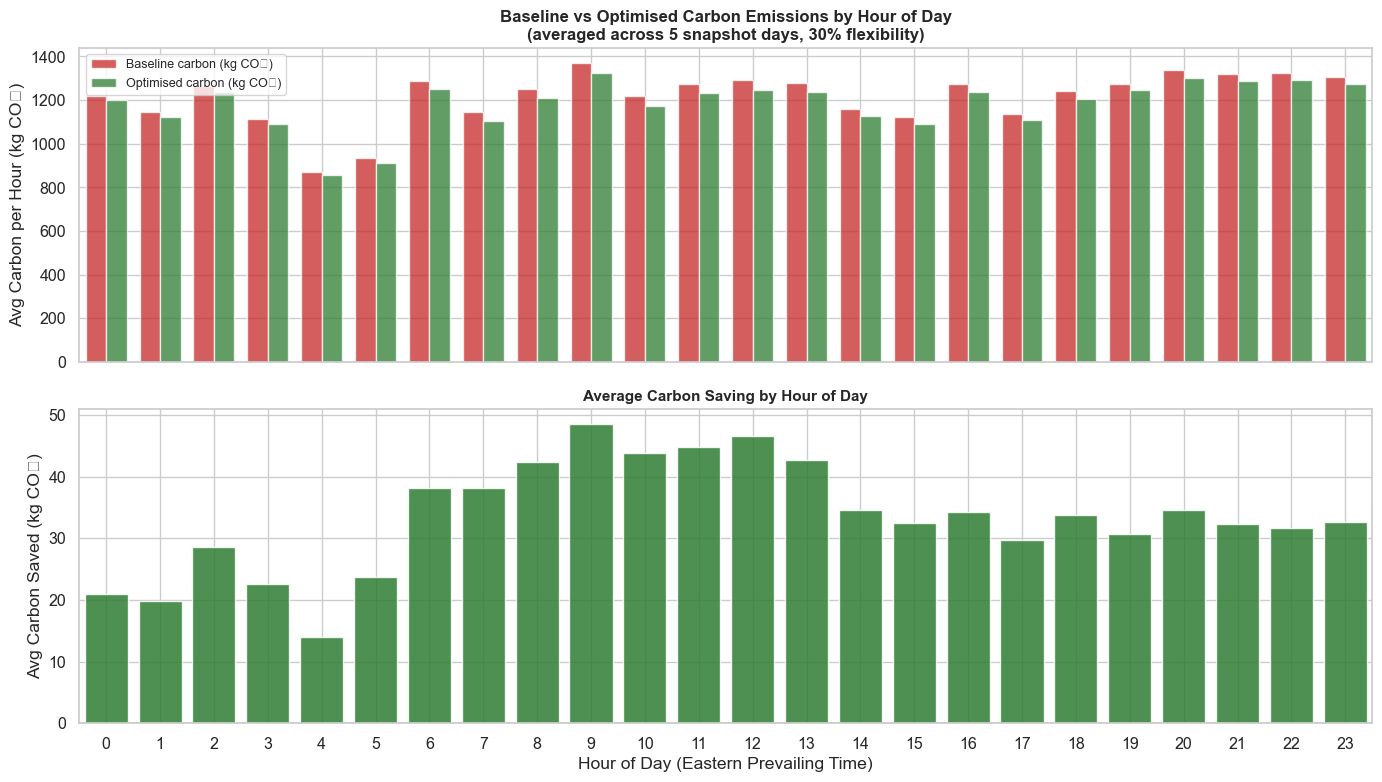

Hour with most savings potential  : 09:00
Hour with least savings potential : 04:00


In [12]:
hourly_avg = integrated.groupby('hour_of_day').agg(
    baseline_kg  = ('baseline_carbon_kg',  'mean'),
    optimized_kg = ('optimized_carbon_kg', 'mean'),
    saved_kg     = ('carbon_saved_kg',     'mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Top: baseline vs optimised bars ─────────────────────────────────
w = 0.38
x = hourly_avg['hour_of_day']
axes[0].bar(x - w/2, hourly_avg['baseline_kg'],  w, color=RED,   alpha=0.75, label='Baseline carbon (kg CO₂)')
axes[0].bar(x + w/2, hourly_avg['optimized_kg'], w, color=GREEN, alpha=0.75, label='Optimised carbon (kg CO₂)')
axes[0].set_ylabel('Avg Carbon per Hour (kg CO₂)')
axes[0].set_title('Baseline vs Optimised Carbon Emissions by Hour of Day\n'
                  '(averaged across 5 snapshot days, 30% flexibility)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# ── Bottom: carbon saved ─────────────────────────────────────────────
colours = [GREEN if v > 0 else GREY for v in hourly_avg['saved_kg']]
axes[1].bar(x, hourly_avg['saved_kg'], color=colours, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xlabel('Hour of Day (Eastern Prevailing Time)')
axes[1].set_ylabel('Avg Carbon Saved (kg CO₂)')
axes[1].set_title('Average Carbon Saving by Hour of Day', fontsize=11, fontweight='bold')

for ax in axes:
    ax.set_xticks(range(0, 24))
    ax.set_xlim(-0.5, 23.5)

plt.tight_layout()
plt.savefig(EDA_DIR / 'eda_integrated_baseline_vs_optimised.png', dpi=150, bbox_inches='tight')
plt.show()

best_hour  = hourly_avg.loc[hourly_avg['saved_kg'].idxmax(), 'hour_of_day']
worst_hour = hourly_avg.loc[hourly_avg['saved_kg'].idxmin(), 'hour_of_day']
print(f'Hour with most savings potential  : {int(best_hour):02d}:00')
print(f'Hour with least savings potential : {int(worst_hour):02d}:00')

### 2.3.3 Summary: the business case in numbers

In [13]:
print('═' * 62)
print('  PHASE 2 — DESCRIPTIVE EDA: KEY FINDINGS')
print('═' * 62)

print('\n── Demand ─────────────────────────────────────────────────')
print(f'  Mean cluster utilisation  : {demand["utilization_rate"].mean():.1%}')
print(f'  Total active energy (5d)  : {demand["active_energy_kWh"].sum():,.0f} kWh')
print(f'  Total shiftable energy    : {demand["shiftable_energy_kWh"].sum():,.0f} kWh (30% flex)')
print(f'  Utilisation range         : {demand["utilization_rate"].min():.1%} – {demand["utilization_rate"].max():.1%}')

print('\n── Supply ─────────────────────────────────────────────────')
ci = supply['carbon_intensity_gCO2_per_kWh']
print(f'  Mean CI (2019–2022)       : {ci.mean():.1f} gCO₂/kWh')
print(f'  CI range                  : {ci.min():.1f} – {ci.max():.1f} gCO₂/kWh')
print(f'  Mean daily CI range       : {daily_range["ci_range"].mean():.1f} gCO₂/kWh')
print(f'  Low-carbon share (avg)    : {supply["low_carbon_share"].mean():.1%}')
ci_2019 = supply[supply['year']==2019]["carbon_intensity_gCO2_per_kWh"].mean()
ci_2022 = supply[supply['year']==2022]["carbon_intensity_gCO2_per_kWh"].mean()
print(f'  CI trend 2019→2022        : {ci_2019:.1f} → {ci_2022:.1f} gCO₂/kWh  ({ci_2022-ci_2019:+.1f})')

print('\n── Integration ────────────────────────────────────────────')
print(f'  Total baseline carbon (5d): {integrated["baseline_carbon_kg"].sum():,.1f} kg CO₂')
print(f'  Total carbon saved (5d)   : {integrated["carbon_saved_kg"].sum():,.1f} kg CO₂  (30% flex)')
print(f'  Mean reduction per day    : {integrated.groupby("snapshot_date")["carbon_reduction_pct"].mean().mean():.2f}%')
print(f'  Projected annual saving   : {integrated["projected_annual_saving_tCO2"].iloc[0]:.1f} tCO₂/year (30% flex)')
print(f'  Sensitivity range         : {integrated["projected_annual_saving_20p_tCO2"].iloc[0]:.1f} – {integrated["projected_annual_saving_40p_tCO2"].iloc[0]:.1f} tCO₂/year')

print('\n── Charts saved ───────────────────────────────────────────')
for png in sorted((PROJECT_ROOT / 'data/processed').glob('eda_*.png')):
    print(f'  ✓  {png.name}')

print()
print('  Phase 2 — Descriptive EDA: COMPLETE')
print('═' * 62)

══════════════════════════════════════════════════════════════
  PHASE 2 — DESCRIPTIVE EDA: KEY FINDINGS
══════════════════════════════════════════════════════════════

── Demand ─────────────────────────────────────────────────
  Mean cluster utilisation  : 68.7%
  Total active energy (5d)  : 459,622 kWh
  Total shiftable energy    : 137,887 kWh (30% flex)
  Utilisation range         : 1.3% – 98.6%

── Supply ─────────────────────────────────────────────────
  Mean CI (2019–2022)       : 283.1 gCO₂/kWh
  CI range                  : 75.7 – 499.9 gCO₂/kWh
  Mean daily CI range       : 51.2 gCO₂/kWh
  Low-carbon share (avg)    : 56.3%
  CI trend 2019→2022        : 301.4 → 293.3 gCO₂/kWh  (-8.2)

── Integration ────────────────────────────────────────────
  Total baseline carbon (5d): 145,807.6 kg CO₂
  Total carbon saved (5d)   : 4,007.6 kg CO₂  (30% flex)
  Mean reduction per day    : 2.62%
  Projected annual saving   : 292.6 tCO₂/year (30% flex)
  Sensitivity range         : 195.0 – 39